# Progetto 2

## Machine Learning

Il dataset **Linnerud** presenta un problema di regressione Multi-Target (3 target totali: *Weight*, *Waist*, *Pulse*).

Addestrare e confrontare alcuni modelli di regressione sul dataset, riducendo il problema da Multi-Target a Single-Target tramite

  1. PCA

  2. selezione manuale di un singolo target

### 1 Data Exploration & Preprocessing

• Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale (i.e. df.describe())

• Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

### 2 Target Engineering

Trasformare il problema Multi-Target in due distinti problemi Single-Target da confrontare:

• PCA (Target Composto)

– Applicare la PCA alla matrice dei target standardizzata e mantenere PC1

• Manuale (Target Selezionato)

– Selezionare il target Waist dalla matrice dei target standardizzata come singolo target rappresentativo 1

### 3 Addestramento & Valutazione

Addestrare i tre modelli di regressione (Linear Regression, Ridge, Lasso) su entrambi gli scenari di target ridotto con PCA e selezione manuale, utilizzando il set di feature completo e standardizzato:

• Definire e inizializzare i tre modelli di regressione (Lineare, Ridge con α = 1.0, Lasso con α = 0.1)

• Eseguire l’addestramento su tutto il dataset per entrambi gli scenari

• Valutare e memorizzare i risultati come Mean Squared Error e R2 Score per ogni combinazione di modello e scenario

### 4 Analisi & Visualizzazione

• Applicare la PCA al set di feature standardizzato e mantenere le due componenti principali PC1 e PC2 per la visualizzazione 2D

• Creare un grafico di dispersione in cui:

– L’asse X `e il PC1 delle Feature

– L’asse Y `e la PCA con n components=1

– Tracciare le tre rette di regressione (Lineare, Ridge, Lasso) ri-addestrate sulla sola PC1 delle Feature, includendo il loro rispettivo R2 Score finale nell’etichetta.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

## 1. Data Exploration & Preprocessing

In [3]:
data = load_linnerud()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=data.target_names)

X.head()

,Chins,Situps,Jumps
0,5.0,162.0,60.0
1,2.0,110.0,60.0
2,12.0,101.0,101.0
3,12.0,105.0,37.0
4,13.0,155.0,58.0


In [4]:
y.head()

,Weight,Waist,Pulse
0,191.0,36.0,50.0
1,189.0,37.0,52.0
2,193.0,38.0,58.0
3,162.0,35.0,62.0
4,189.0,35.0,46.0


In [5]:
X.describe()

,Chins,Situps,Jumps
count,20.000000,20.000000,20.00000
mean,9.450000,145.550000,70.30000
std,5.286278,62.566575,51.27747
min,1.000000,50.000000,25.00000
25%,4.750000,101.000000,39.50000
50%,11.500000,122.500000,54.00000
75%,13.250000,210.000000,85.25000
max,17.000000,251.000000,250.00000


In [6]:
y.describe()

,Weight,Waist,Pulse
count,20.000000,20.000000,20.000000
mean,178.600000,35.400000,56.100000
std,24.690505,3.201973,7.210373
min,138.000000,31.000000,46.000000
25%,160.750000,33.000000,51.500000
50%,176.000000,35.000000,55.000000
75%,191.500000,37.000000,60.500000
max,247.000000,46.000000,74.000000


In [7]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

## 2. Target Engineering

### 2.1 PCA sui target

In [9]:
pca_target = PCA(n_components=1)
y_pca = pca_target.fit_transform(y_scaled)

### 2.2 Selezione manuale (Waist)

In [10]:
y_waist = y_scaled[:, 1].reshape(-1, 1)

## 3. Addestramento & Valutazione

In [13]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

In [22]:
results = []

targets = {
    "PCA": y_pca,
    "Waist": y_waist
}

for target_name, y_target in targets.items():
    for model_name, model in models.items():
        
        model.fit(X_scaled, y_target)
        preds = model.predict(X_scaled)
        
        mse = mean_squared_error(y_target, preds)
        r2 = r2_score(y_target, preds)
        
        results.append({
            "Scenario": target_name,
            "Model": model_name,
            "MSE": mse,
            "R2": r2
        })

results_df = pd.DataFrame(results)
print(results_df)

  Scenario   Model       MSE        R2
0      PCA  Linear  1.268880  0.396958
1      PCA   Ridge  1.275908  0.393618
2      PCA   Lasso  1.332376  0.366781
3    Waist  Linear  0.452156  0.547844
4    Waist   Ridge  0.456687  0.543313
5    Waist   Lasso  0.515654  0.484346


## 4. Visualizzazione

In [15]:
pca_features = PCA(n_components=2)
X_pca = pca_features.fit_transform(X_scaled)

PC1 = X_pca[:, 0].reshape(-1, 1)

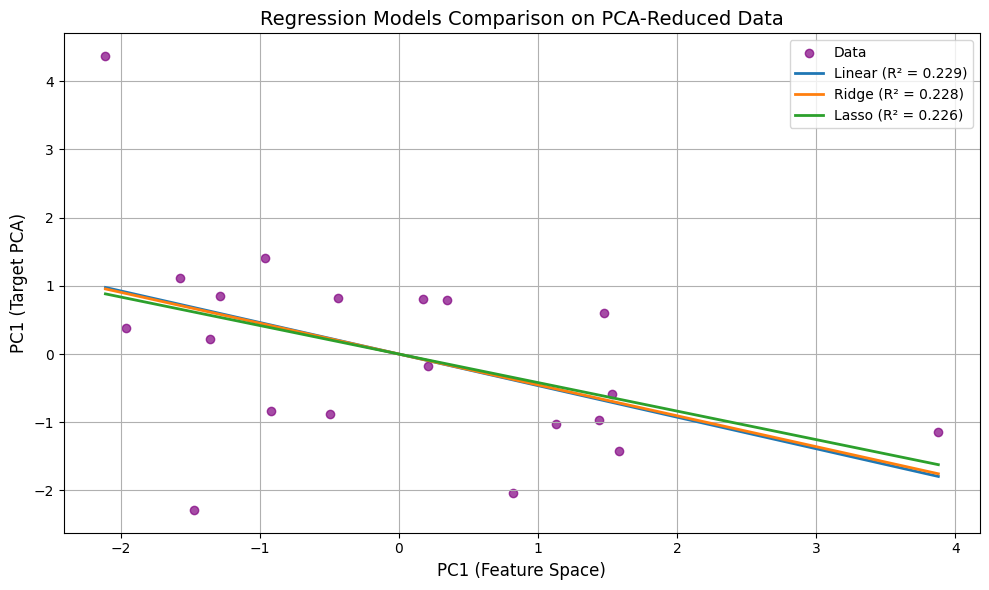

In [21]:
y_plot = y_pca

plt.figure(figsize=(10, 6))
plt.scatter(PC1, y_plot, color='purple', label="Data", alpha=0.7)

x_line = np.linspace(PC1.min(), PC1.max(), 100).reshape(-1, 1)

for name, model in models.items():
    model.fit(PC1, y_plot)
    y_line = model.predict(x_line)
    
    r2 = r2_score(y_plot, model.predict(PC1))
    
    plt.plot(x_line, y_line, linewidth=2, label=f"{name} (R² = {r2:.3f})")

plt.xlabel("PC1 (Feature Space)", fontsize=12)
plt.ylabel("PC1 (Target PCA)", fontsize=12)
plt.title("Regression Models Comparison on PCA-Reduced Data", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()